## Breast Cancer Diagnosis — ML Analysis

---
### 1. Setup

**1.1 Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

**1.2 Configuration**

In [10]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style='whitegrid')

**1.3 Load Data**

In [ ]:
PATH = 'breast_cancer_dataset.csv'

df_bc = pd.read_csv(PATH)
print(f"Dataset loaded — {df_bc.shape[0]} rows, {df_bc.shape[1]} columns")

Dataset loaded — 569 rows, 32 columns


---
### 2. Exploratory Data Analysis (EDA) & Data Cleaning

**2.1 Quick Look at the Data**

In [5]:
df_bc.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [4]:
df_bc = df_bc.drop(columns=['id'])

row, col = df_bc.shape
print(f"Rows   : {row}")
print(f"Columns: {col}")

Rows   : 569
Columns: 31


**2.2 Column Info**

In [6]:
print(f"{'#':<3} | {'Column Name':<25} | {'Data Type'}")
print("-" * 45)

for i, (col_name, col_type) in enumerate(df_bc.dtypes.items()):
    print(f"{i+1:<3} | {col_name:<25} | {str(col_type)}")

#   | Column Name               | Data Type
---------------------------------------------
1   | diagnosis                 | str
2   | radius_mean               | float64
3   | texture_mean              | float64
4   | perimeter_mean            | float64
5   | area_mean                 | float64
6   | smoothness_mean           | float64
7   | compactness_mean          | float64
8   | concavity_mean            | float64
9   | concave points_mean       | float64
10  | symmetry_mean             | float64
11  | fractal_dimension_mean    | float64
12  | radius_se                 | float64
13  | texture_se                | float64
14  | perimeter_se              | float64
15  | area_se                   | float64
16  | smoothness_se             | float64
17  | compactness_se            | float64
18  | concavity_se              | float64
19  | concave points_se         | float64
20  | symmetry_se               | float64
21  | fractal_dimension_se      | float64
22  | radius_worst              

**2.3 Data Quality Checks**

In [7]:
missing_cols = df_bc.columns[df_bc.isnull().any()].tolist()
duplicates   = df_bc.duplicated().sum()

print(f"Columns with missing values : {missing_cols if missing_cols else 'None'}")
print(f"Duplicate rows              : {duplicates}")

Columns with missing values : None
Duplicate rows              : 0


**2.4 Target Class Distribution**
> **Note:** The dataset is slightly imbalanced (~63% Benign, ~37% Malignant).  
> That's why we optimize for **Recall** — missing a cancer case is more costly than a false alarm.

In [8]:
counts      = df_bc['diagnosis'].value_counts()
percentages = df_bc['diagnosis'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': counts, 'Percentage (%)': round(percentages, 1)})
print(summary)

df_bc['diagnosis'] = df_bc['diagnosis'].map({'M': 1, 'B': 0})

           Count  Percentage (%)
diagnosis                       
B            357          62.700
M            212          37.300


---
### 3. Data Visualization

**3.1 Feature Distributions (by Diagnosis)**

Violin plots split by diagnosis show how each feature separates Benign from Malignant — much more informative than looking at the overall distribution alone.

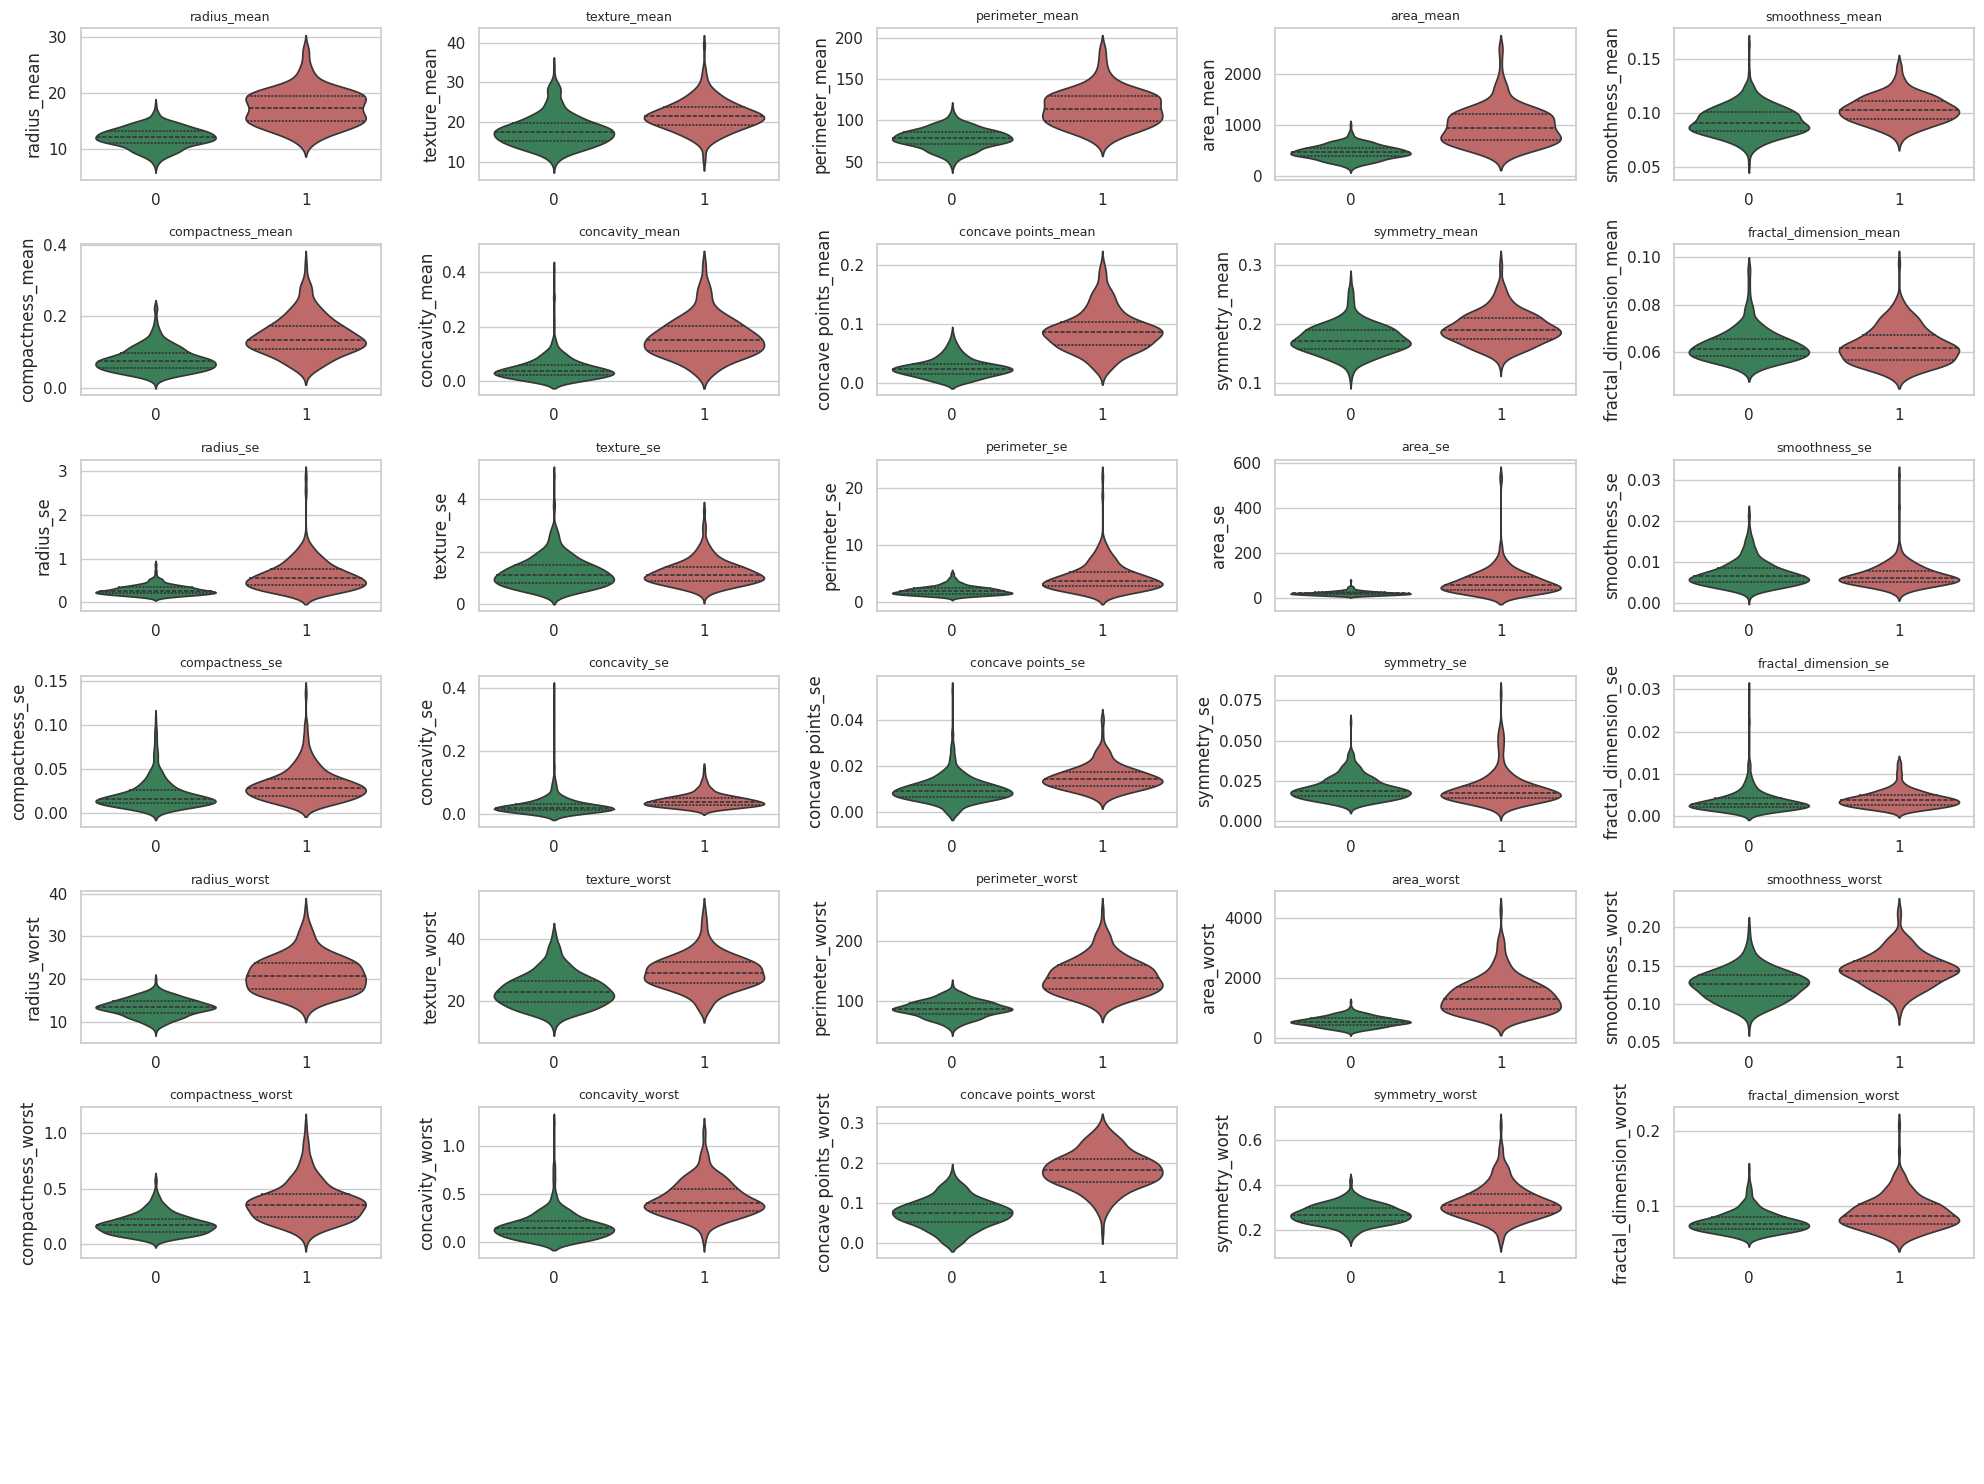

In [15]:
PALETTE = {0: "seagreen", 1: "indianred"}
df_bc['diagnosis'] = df_bc['diagnosis'].astype(int)
features = df_bc.select_dtypes(include=['number']).drop(columns=['diagnosis']).columns

fig, axes = plt.subplots(7, 5, figsize=(20, 15))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(
        data=df_bc,
        x='diagnosis',
        y=feat,
        ax=axes[i],
        palette=PALETTE,
        hue='diagnosis',
        legend=False,
        inner='quartile'
    )
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**3.2 Correlation Heatmap**

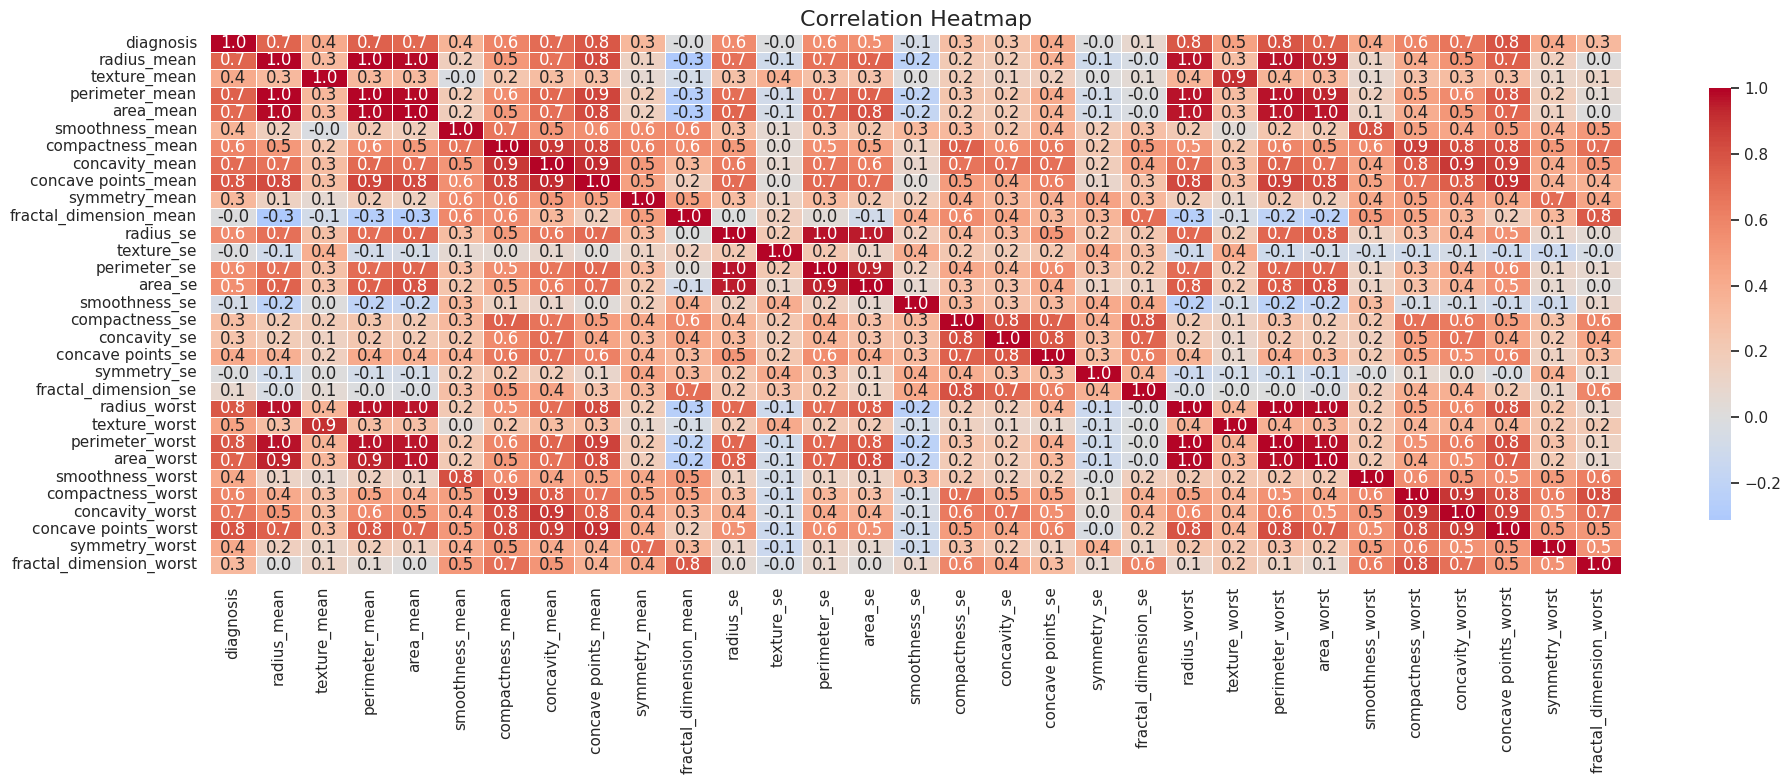

In [17]:
corr_matrix = df_bc.corr(numeric_only=True)

plt.figure(figsize=(20, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.1f',
    linewidths=0.5,
    center=0,
    cbar_kws={'shrink': .8}
)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

**3.3 Top 10 Features Most Correlated with Diagnosis**

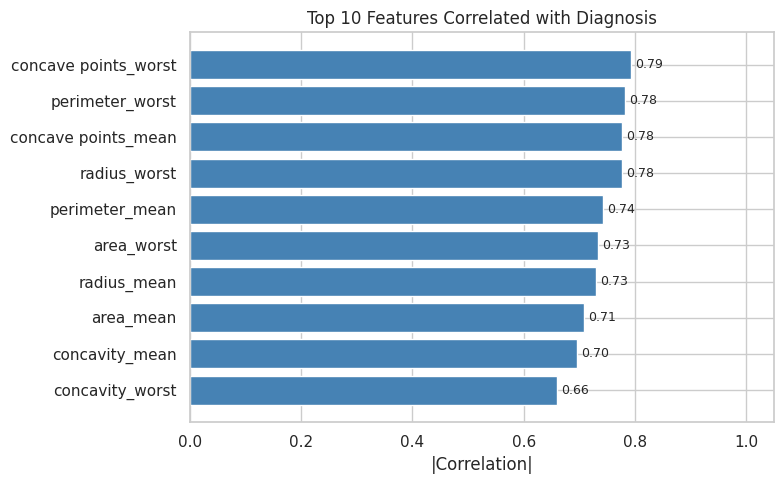

In [20]:
target_corr = (
    df_bc.corr(numeric_only=True)['diagnosis']
    .drop('diagnosis')
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
bars = plt.barh(target_corr.head(10).index, target_corr.head(10).values, color='steelblue')
plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

plt.title('Top 10 Features Correlated with Diagnosis')
plt.xlabel('|Correlation|')

plt.xlim(0, 1.05)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
### 4. Data Preprocessing

**4.1 Train / Test Split**

In [ ]:
X = df_bc.drop(columns=['diagnosis'])
y = df_bc['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Full dataset : {X.shape}")
print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Full dataset : (569, 30)
Training set : (455, 30)
Test set     : (114, 30)


**4.2 PCA — How Many Components Do We Need?**

Before running GridSearch, let's see how much variance is captured per component.  
This helps us understand *why* the best model picked a certain number of components.

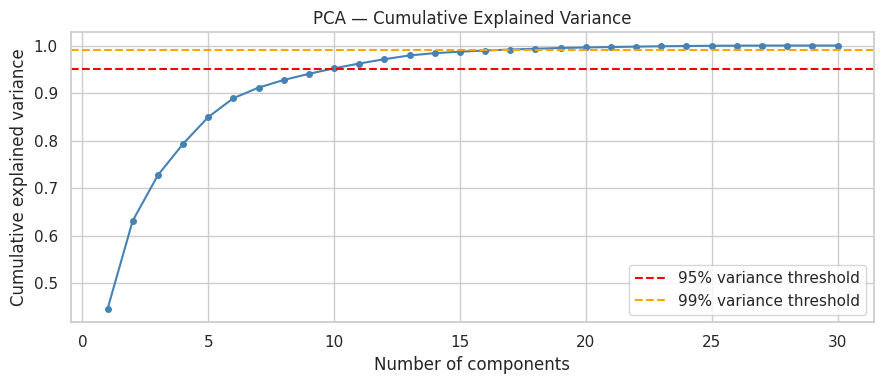

90% variance explained by 7 components
95% variance explained by 10 components
99% variance explained by 17 components


In [22]:
X_scaled = StandardScaler().fit_transform(X_train)

pca_full  = PCA().fit(X_scaled)
cumvar    = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', ms=4, color='steelblue')
plt.axhline(0.95, color='red',   ls='--', label='95% variance threshold')
plt.axhline(0.99, color='orange',ls='--', label='99% variance threshold')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    n = next(i + 1 for i, v in enumerate(cumvar) if v >= threshold)
    print(f"{threshold*100:.0f}% variance explained by {n} components")

---
### 5. Model Training & Optimization

**5.1 Pipeline**

Using a pipeline ensures that scaling and PCA are always applied in the right order, and prevents data leakage during cross-validation.

In [23]:
pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('pca',        PCA()),
    ('classifier', LogisticRegression(max_iter=1000))
])

**5.2 Hyperparameter Grid**

In [24]:
param_grid = [
    # 1. SVC with RBF kernel + PCA
    {
        'classifier': [SVC()],
        'pca': [PCA()],
        'pca__n_components': [10, 20, 30],
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': [0.001, 0.01, 'scale']
    },
    # 2. SVC with Linear kernel + PCA
    {
        'classifier': [SVC()],
        'pca': [PCA()],
        'pca__n_components': [10, 20, 30],
        'classifier__kernel': ['linear'],
        'classifier__C': [0.1, 1, 10]
    },
    # 3. SVC with RBF kernel — no PCA
    {
        'classifier': [SVC()],
        'pca': ['passthrough'],
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': [0.001, 0.01, 'scale']
    },
    # 4. SVC with Linear kernel — no PCA
    {
        'classifier': [SVC()],
        'pca': ['passthrough'],
        'classifier__kernel': ['linear'],
        'classifier__C': [0.1, 1, 10]
    },
    # 5. Logistic Regression + PCA
    {
        'classifier': [LogisticRegression(max_iter=1000)],
        'pca': [PCA()],
        'pca__n_components': [10, 20],
        'classifier__C': [0.1, 1, 10]
    },
    # 6. Logistic Regression — no PCA
    {
        'classifier': [LogisticRegression(max_iter=1000)],
        'pca': ['passthrough'],
        'classifier__C': [0.1, 1, 10]
    }
]

**5.3 Cross-Validation & Grid Search**

We optimize for **Recall** — in cancer diagnosis, we'd rather have a false alarm than miss a real case.

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 57 candidates, totalling 285 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier': [SVC()], 'classifier__C': [0.1, 1, ...], 'classifier__gamma': [0.001, 0.01, ...], 'classifier__kernel': ['rbf'], ...}, {'classifier': [SVC()], 'classifier__C': [0.1, 1, ...], 'classifier__kernel': ['linear'], 'pca': [PCA()], ...}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",S

**5.4 Best Model Summary**

In [26]:
print("=" * 50)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 50)
print(f"Best CV Recall  : {grid_search.best_score_:.4f}")
print()
print("Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<30} : {v}")

HYPERPARAMETER TUNING RESULTS
Best CV Recall  : 0.9647

Best parameters:
  classifier                     : SVC()
  classifier__C                  : 10
  classifier__gamma              : scale
  classifier__kernel             : rbf
  pca                            : PCA()
  pca__n_components              : 10


**5.5 Top 5 Model Configurations**

In [27]:
results_df = pd.DataFrame(grid_search.cv_results_)
best_models = results_df[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

print("Top 5 Model Configurations:")
display(best_models.head(5))

Top 5 Model Configurations:


,params,mean_test_score,rank_test_score
26,"{'classifier': SVC(), 'classifier__C': 10, 'cl...",0.965,1
24,"{'classifier': SVC(), 'classifier__C': 10, 'cl...",0.965,1
25,"{'classifier': SVC(), 'classifier__C': 10, 'cl...",0.965,1
44,"{'classifier': SVC(), 'classifier__C': 10, 'cl...",0.965,1
30,"{'classifier': SVC(), 'classifier__C': 1, 'cla...",0.959,5


**5.6 Cross-Validation Stability**

One score isn't enough — let's check how consistent the best model is across all 5 folds.

Recall per fold : ['0.9118', '1.0000', '0.9706', '0.9706', '0.9706']
Mean            : 0.9647
Std             : 0.0288


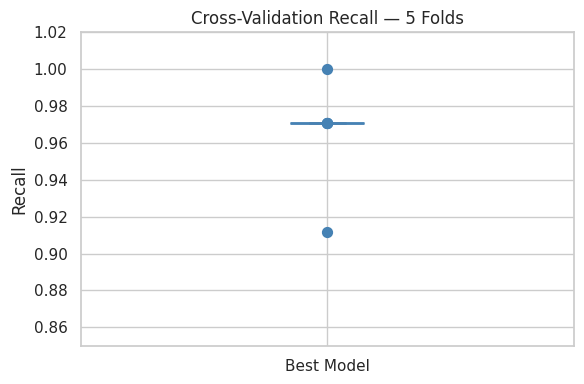

In [28]:
cv_scores = cross_val_score(
    grid_search.best_estimator_,
    X_train, y_train,
    cv=skf,
    scoring='recall'
)

print(f"Recall per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean            : {cv_scores.mean():.4f}")
print(f"Std             : {cv_scores.std():.4f}")

plt.figure(figsize=(6, 4))
plt.boxplot(cv_scores, vert=True, patch_artist=True,
            boxprops=dict(facecolor='#B5D4F4', color='steelblue'),
            medianprops=dict(color='steelblue', linewidth=2))
plt.scatter([1] * len(cv_scores), cv_scores, color='steelblue', zorder=5, s=50)
plt.title('Cross-Validation Recall — 5 Folds')
plt.ylabel('Recall')
plt.xticks([1], ['Best Model'])
plt.ylim(0.85, 1.02)
plt.tight_layout()
plt.show()

---
### 6. Model Evaluation

**6.1 Train vs Test — Results Summary**

In [29]:
def get_metrics(y_true, y_pred, split_name):
    return {
        'Split':     split_name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred),
    }

y_train_pred = grid_search.predict(X_train)
y_test_pred  = grid_search.predict(X_test)

results_df = pd.DataFrame([
    get_metrics(y_train, y_train_pred, 'Train'),
    get_metrics(y_test,  y_test_pred,  'Test'),
]).set_index('Split')

print(results_df.to_string())

       Accuracy  Precision  Recall  F1-Score
Split                                       
Train     0.989      1.000   0.971     0.985
Test      0.965      0.975   0.929     0.951


**6.2 Detailed Classification Report**

In [30]:
print("TRAIN SET")
print("-" * 50)
print(classification_report(y_train, y_train_pred,
                            target_names=['Benign', 'Malignant'], digits=4))

print("TEST SET")
print("-" * 50)
print(classification_report(y_test, y_test_pred,
                            target_names=['Benign', 'Malignant'], digits=4))

TRAIN SET
--------------------------------------------------
              precision    recall  f1-score   support

      Benign     0.9828    1.0000    0.9913       285
   Malignant     1.0000    0.9706    0.9851       170

    accuracy                         0.9890       455
   macro avg     0.9914    0.9853    0.9882       455
weighted avg     0.9892    0.9890    0.9890       455

TEST SET
--------------------------------------------------
              precision    recall  f1-score   support

      Benign     0.9595    0.9861    0.9726        72
   Malignant     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



**6.3 Confusion Matrices (Train & Test)**

Each cell shows the **count** and the **row percentage** — easier to spot False Negatives (missed cancer cases).

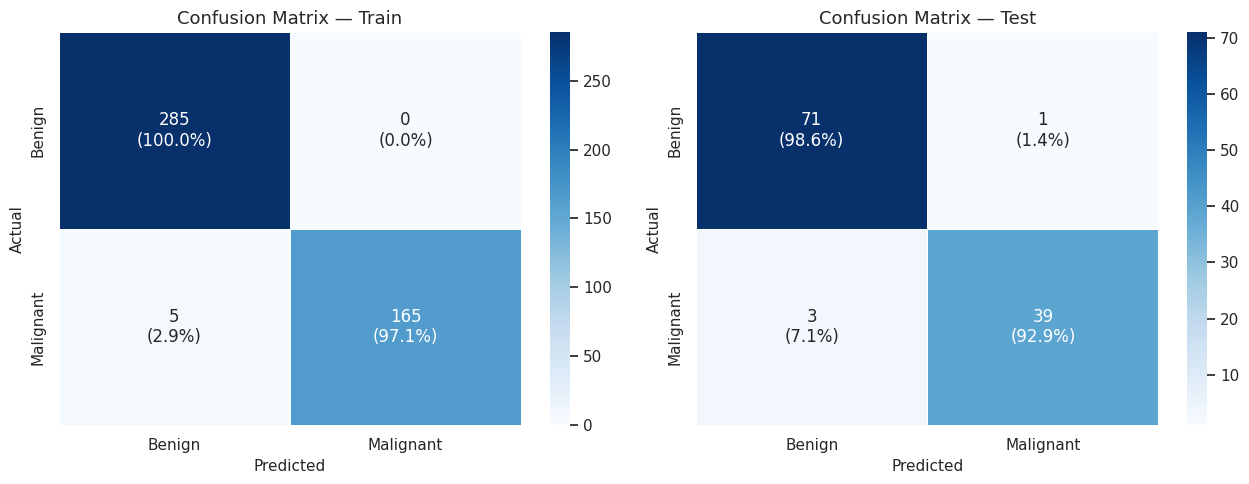

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    annot = [
        [f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ]

    sns.heatmap(
        cm, annot=annot, fmt='', cmap='Blues', ax=ax,
        xticklabels=['Benign', 'Malignant'],
        yticklabels=['Benign', 'Malignant'],
        linewidths=0.5
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(y_train, y_train_pred, 'Confusion Matrix — Train', ax1)
plot_confusion_matrix(y_test,  y_test_pred,  'Confusion Matrix — Test',  ax2)

plt.tight_layout()
plt.show()

**6.4 ROC Curve**

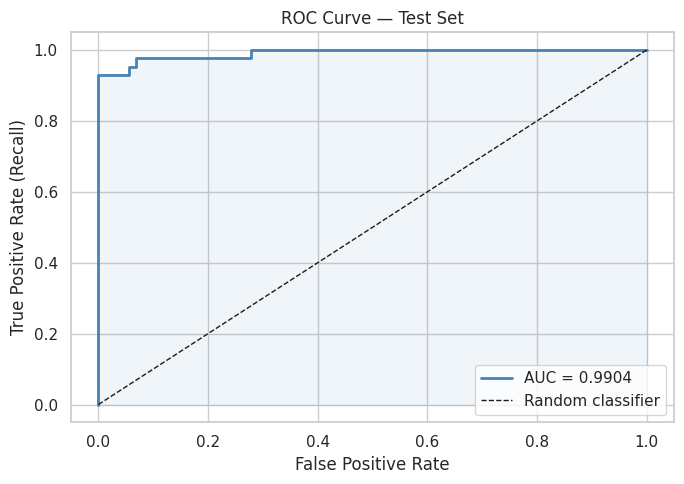

In [32]:
y_scores = grid_search.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc_value   = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_value:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**6.5 Precision-Recall Curve**

With imbalanced classes, the PR Curve is more informative than the ROC Curve.  
It directly shows the trade-off between catching all cancer cases (recall) and avoiding false alarms (precision).

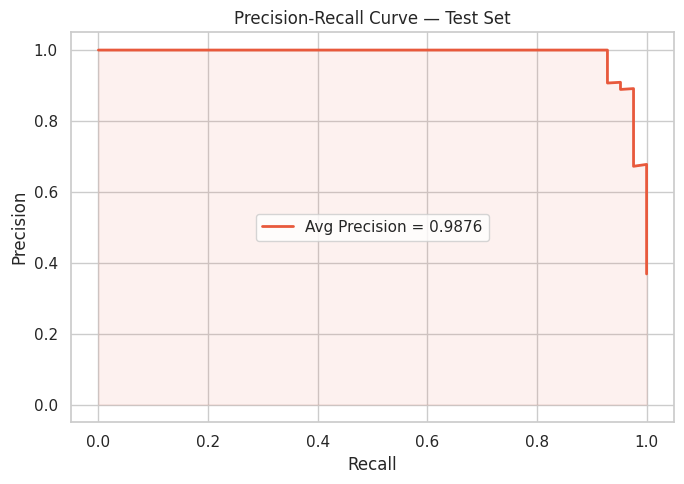

In [33]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals, color='#E8593C', lw=2, label=f'Avg Precision = {ap:.4f}')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='#E8593C')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Test Set')
plt.legend()
plt.tight_layout()
plt.show()